In [23]:
# Install nltk (usually pre-installed)
import nltk
nltk.download('stopwords')
nltk.download('punkt')

# Import libraries
import pandas as pd
import numpy as np
import re

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [24]:
!pip install datasets


In [25]:
from datasets import load_dataset
import pandas as pd

# Load dataset using API
dataset = load_dataset("imdb")

# Convert training split to DataFrame
df = pd.DataFrame(dataset['train'])

# Convert label numbers to text
df['sentiment'] = df['label'].map({0: 'negative', 1: 'positive'})

# Keep required columns only
df = df[['text', 'sentiment']]

# Rename column to match rest of code
df.rename(columns={'text': 'review'}, inplace=True)

df.head()


,review,sentiment
0,I rented I AM CURIOUS-YELLOW from my video sto...,negative
1,"""I Am Curious: Yellow"" is a risible and preten...",negative
2,If only to avoid making this type of film in t...,negative
3,This film was probably inspired by Godard's Ma...,negative
4,"Oh, brother...after hearing about this ridicul...",negative


In [26]:
df['sentiment'] = df['sentiment'].map({'positive':1, 'negative':0})


In [27]:
ps = PorterStemmer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = re.sub('[^a-zA-Z]', ' ', text)
    text = text.lower()
    words = text.split()
    words = [ps.stem(word) for word in words if word not in stop_words]
    return ' '.join(words)

df['cleaned_review'] = df['review'].apply(clean_text)


In [28]:
X = df['cleaned_review']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [29]:
cv = CountVectorizer(max_features=5000)

X_train_cv = cv.fit_transform(X_train)
X_test_cv = cv.transform(X_test)


In [30]:
model = MultinomialNB()
model.fit(X_train_cv, y_train)


MultinomialNB()

In [31]:
y_pred = model.predict(X_test_cv)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.8486
              precision    recall  f1-score   support

           0       0.85      0.85      0.85      2515
           1       0.85      0.84      0.85      2485

    accuracy                           0.85      5000
   macro avg       0.85      0.85      0.85      5000
weighted avg       0.85      0.85      0.85      5000



In [32]:
def predict_sentiment(review):
    review = clean_text(review)
    vector = cv.transform([review])
    prediction = model.predict(vector)

    if prediction[0] == 1:
        return "Positive 😊"
    else:
        return "Negative 😞"

# Test
predict_sentiment("The product quality is amazing and worth the price")


'Positive 😊'

In [33]:
def predict_sentiment(user_review):
    # Clean the user input
    cleaned = clean_text(user_review)

    # Convert text to vector
    vector = cv.transform([cleaned])

    # Predict sentiment
    prediction = model.predict(vector)[0]

    # Return result
    if prediction == 1:
        return "Positive 😊"
    else:
        return "Negative 😞"


In [34]:
user_feedback = input("Enter your review ⌨️: ")
result = predict_sentiment(user_feedback)
print("Sentiment:", result)


Enter your review ⌨️: good
Sentiment: Positive 😊


In [35]:
from IPython.display import display, HTML
from google.colab import output

In [36]:
def predict_from_ui(text):
    return predict_sentiment(text)

output.register_callback('notebook.predict', predict_from_ui)

In [37]:
from google.colab import output

def predict_from_ui(text):
    return predict_sentiment(text)

output.register_callback('notebook.predict_sentiment', predict_from_ui)

In [38]:
import base64

with open("/content/Sentiment-Analyzer.jpg", "rb") as f:
    image_data = base64.b64encode(f.read()).decode()


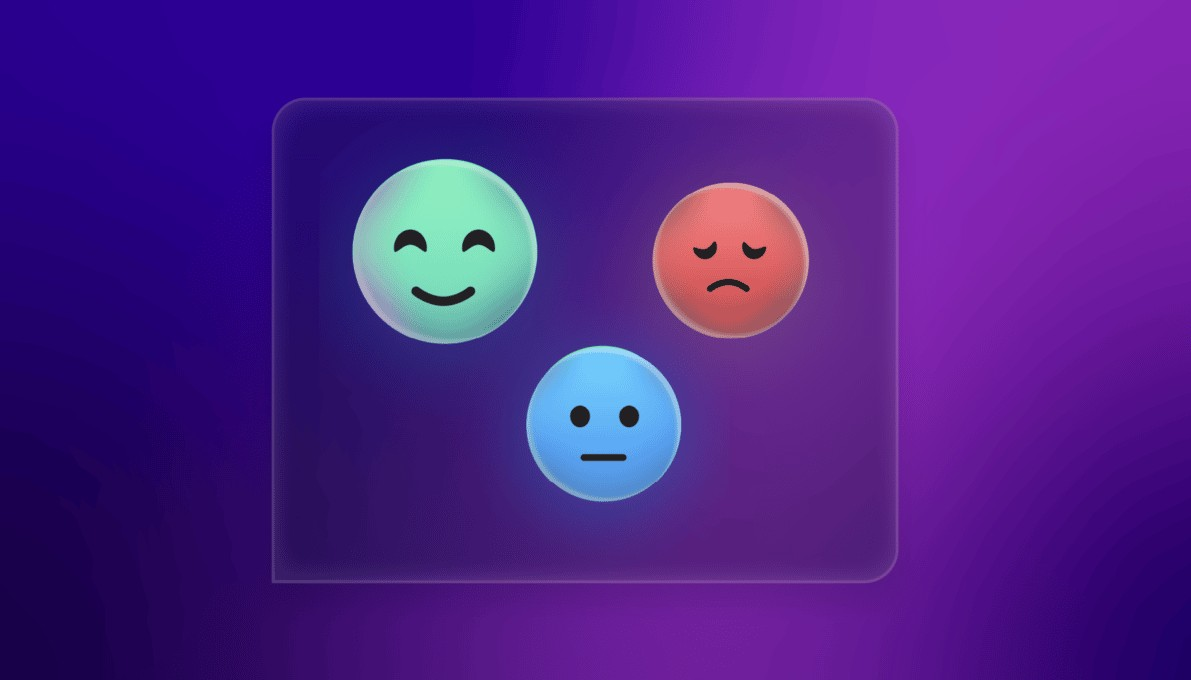

In [39]:
from IPython.display import display, HTML

display(HTML(f"""

<style>
body {{

    margin:0;
    height:100vh;
    display:flex;
    justify-content:center;
    align-items:center;
    background-image:url("data:image/jpg;base64,{image_data}");
    background-size:cover;
    background-position:center;
    font-family:Arial;

}}

.container {{
    width: 400px;
    padding: 25px;
    display: flex;
    flex-direction: column;
    gap: 10px;
    border-radius: 12px;
    background-color: rgb(159, 129, 213);
    box-shadow: 0 8px 20px rgba(84, 67, 71, 0.15);

}}

h2 {{
  text-align: center;
  color: #030010;
  font-size: 30px;
  }}

textarea {{
height:120px;
border-radius:6px;
border:1px solid #ccc;
}}

button {{
  width: 100%;
  padding: 10px;
  margin-top: 10px;
  border: none;
  border-radius: 8px;
  background-color: #624c8b;
  color: #0f151a;
  font-size: 15px;
  font-weight: bold;
  cursor: pointer;
}}

#result {{
margin-top:15px;
font-size:18px;
font-weight:bold;
text-align:center;

}}

button:hover {{
  background-color: rgb(74, 54, 165);
  }}

</style>

<div class="container">

<h2>🎬 Sentiment Analyzer</h2>

<textarea id="review" placeholder="Enter your movie review"></textarea>

<button onclick="analyze()">Analyze Sentiment</button>

<h3 id="result"></h3>

</div>

<script>

async function analyze() {{

let text = document.getElementById("review").value;

if(text.length == 0) {{
document.getElementById("result").innerHTML = "Please enter a review";
return;
}}

const response = await google.colab.kernel.invokeFunction(
'notebook.predict_sentiment',
[text],
{{}}
);

document.getElementById("result").innerHTML =
"Sentiment: " + response.data['text/plain'];

}}

</script>

"""))

In [40]:
import pickle

# Save the trained model
pickle.dump(model, open("sentiment_model.pkl", "wb"))

# Save the vectorizer
pickle.dump(cv, open("vectorizer.pkl", "wb"))